### Your Paths
```
Videos   : F:\2014741\Raw_Videos_Unified\<class>\<video>.mp4
Features : F:\2014741\TimeSformer_Features\<class>\<video>.npy
Output   : F:\2014741\Stage2_Captions\
```

---
## Section 1: Imports & Configuration
---

In [1]:
"""
Stage 2: Imports and Configuration
"""

import os
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from scipy.ndimage import gaussian_filter1d
from pathlib import Path
from PIL import Image
from typing import Dict, List, Optional, Tuple
import json
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
#  HF_CACHE — set BEFORE importing transformers
# ─────────────────────────────────────────────
os.environ['HF_HOME']           = r"F:\2014741\HF_Models"
os.environ['TRANSFORMERS_CACHE'] = r"F:\2014741\HF_Models\transformers"
os.environ['HF_DATASETS_CACHE']  = r"F:\2014741\HF_Models\datasets"

# ─────────────────────────────────────────────
#  YOUR PATHS
# ─────────────────────────────────────────────
MODEL_PATH      = r"F:\2014741\MIL_Models\best_model.pth"
FEATURES_ROOT   = r"F:\2014741\TimeSformer_Features"
VIDEOS_ROOT     = r"F:\2014741\Raw_Videos_Unified"
STAGE2_OUT      = r"F:\2014741\Stage2_Captions"

os.makedirs(STAGE2_OUT, exist_ok=True)

# ─────────────────────────────────────────────
#  MIL PARAMS (must match Stage 1)
# ─────────────────────────────────────────────
FEATURE_DIM       = 768
HIDDEN_DIM_1      = 512
HIDDEN_DIM_2      = 128
DROPOUT_RATE      = 0.6
TOP_K             = 3
NUM_SEGMENTS      = 16
ANOMALY_THRESHOLD = 0.5
SMOOTHING_SIGMA   = 2

# ─────────────────────────────────────────────
#  FRAME EXTRACTION PARAMS (from your Phase 5)
# ─────────────────────────────────────────────
BEFORE_POSITION = 0.15   # 15% into anomaly region
PEAK_POSITION   = 0.50   # 50% — main event
AFTER_POSITION  = 0.85   # 85% — aftermath
FRAME_SIZE      = (224, 224)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("STAGE 2 — FRAME EXTRACTION + VLM CAPTIONING")
print("=" * 60)
print(f"  Device  : {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU     : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"  Videos  : {VIDEOS_ROOT}")
print(f"  Output  : {STAGE2_OUT}")
print(f"  HF Cache: {os.environ['HF_HOME']}")
print("=" * 60)

STAGE 2 — FRAME EXTRACTION + VLM CAPTIONING
  Device  : cuda
  GPU     : NVIDIA GeForce RTX 4080 SUPER
  VRAM    : 16.0 GB
  Videos  : F:\2014741\Raw_Videos_Unified
  Output  : F:\2014741\Stage2_Captions
  HF Cache: F:\2014741\HF_Models


---
## Section 2: Reload Stage 1 (MIL Model)
Copy of Stage 1 so this notebook is self-contained.

---

In [2]:
"""
Stage 1 code — copied here so Stage 2 is fully self-contained.
"""

class MILNetwork(nn.Module):
    def __init__(self, feature_dim=FEATURE_DIM, hidden_dim_1=HIDDEN_DIM_1,
                 hidden_dim_2=HIDDEN_DIM_2, dropout_rate=DROPOUT_RATE, top_k=TOP_K):
        super().__init__()
        self.top_k   = top_k
        self.fc1     = nn.Linear(feature_dim, hidden_dim_1)
        self.fc2     = nn.Linear(hidden_dim_1, hidden_dim_2)
        self.fc3     = nn.Linear(hidden_dim_2, 1)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        batch_size, num_segments, _ = x.shape
        x = x.view(-1, x.shape[-1])
        x = F.relu(self.fc1(x)); x = self.dropout(x)
        x = F.relu(self.fc2(x)); x = self.dropout(x)
        x = torch.sigmoid(self.fc3(x))
        segment_scores = x.view(batch_size, num_segments)
        topk_scores, _ = torch.topk(segment_scores, k=self.top_k, dim=1)
        return topk_scores.mean(dim=1), segment_scores


def load_mil_model(model_path=MODEL_PATH):
    model      = MILNetwork().to(DEVICE)
    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
    if "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)
    model.eval()
    print(f"✅ MIL model loaded — epoch {checkpoint.get('epoch','N/A')}, "
          f"val_auc {checkpoint.get('val_auc', 0):.4f}")
    return model


def run_mil_inference(npy_path, model):
    features  = np.load(npy_path)
    num_clips = features.shape[0]
    indices   = np.linspace(0, num_clips - 1, NUM_SEGMENTS, dtype=int)
    sampled   = features[indices]
    tensor    = torch.FloatTensor(sampled).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        video_score, segment_scores = model(tensor)
    video_score   = video_score.item()
    seg_scores_np = segment_scores.squeeze().cpu().numpy()
    smoothed      = gaussian_filter1d(seg_scores_np, sigma=SMOOTHING_SIGMA)
    return {
        "video_score"      : round(video_score, 4),
        "is_anomaly"       : video_score > ANOMALY_THRESHOLD,
        "segment_scores"   : seg_scores_np.tolist(),
        "smoothed_scores"  : smoothed.tolist(),
        "anomaly_segments" : np.where(smoothed > ANOMALY_THRESHOLD)[0].tolist(),
        "peak_segment"     : int(np.argmax(smoothed)),
        "num_clips"        : num_clips,
    }


def find_file(name, root, extensions=('.npy',)):
    """Search recursively for a file by stem name."""
    stem = Path(name).stem
    for r, _, files in os.walk(root):
        for f in files:
            if Path(f).stem == stem and Path(f).suffix in extensions:
                return os.path.join(r, f)
    return None


# Load model
mil_model = load_mil_model()

✅ MIL model loaded — epoch 62, val_auc 0.9527


---
## Section 3: Smart Frame Extraction
Maps MIL segment scores → actual frame indices → extracts Before/Peak/After frames.

---

In [3]:
"""
Smart Frame Extraction using MIL anomaly scores.
Based on your Phase 5 logic — selects frames at 15% / 50% / 85%
of the anomaly region, NOT random frames.
"""

def segment_to_frame_range(seg_idx: int, num_clips: int,
                            num_segments: int = NUM_SEGMENTS) -> Tuple[int, int]:
    """
    Convert a segment index (0-15) to the actual clip range it covers.
    Returns (start_clip, end_clip) indices.
    """
    clips_per_seg = num_clips / num_segments
    start = int(seg_idx * clips_per_seg)
    end   = int((seg_idx + 1) * clips_per_seg) - 1
    end   = min(end, num_clips - 1)
    return start, end


def extract_frame_from_video(video_path: str, frame_idx: int,
                              size: Tuple = FRAME_SIZE) -> Optional[np.ndarray]:
    """
    Extract a single frame from a video file by frame index.
    Returns numpy array (H, W, 3) in RGB.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"  ❌ Cannot open video: {video_path}")
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_idx    = min(frame_idx, total_frames - 1)

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        return None

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, size)
    return frame


def extract_key_frames(video_path: str, mil_result: Dict) -> Dict:
    """
    Extract Before / Peak / After frames guided by MIL segment scores.

    Strategy:
      - Find the anomaly region (first→last anomaly segment)
      - Extract frame at 15% = BEFORE (early context)
      - Extract frame at 50% = PEAK   (main incident)
      - Extract frame at 85% = AFTER  (aftermath)

    Returns dict with 'before', 'peak', 'after' as numpy arrays + metadata.
    """
    cap         = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps          = cap.get(cv2.CAP_PROP_FPS)
    cap.release()

    num_clips        = mil_result['num_clips']
    anomaly_segments = mil_result['anomaly_segments']
    peak_segment     = mil_result['peak_segment']

    if not anomaly_segments:
        # Fallback: use peak segment only
        anomaly_segments = [peak_segment]

    # Get full anomaly region span
    first_seg = anomaly_segments[0]
    last_seg  = anomaly_segments[-1]

    # Convert segments to clip indices
    region_start_clip, _ = segment_to_frame_range(first_seg, num_clips)
    _, region_end_clip   = segment_to_frame_range(last_seg,  num_clips)
    peak_start, peak_end = segment_to_frame_range(peak_segment, num_clips)

    # Clip-to-frame mapping
    # Each clip = SEQ_LEN=16 frames, stride=5 (from Phase 1)
    # Frame index ≈ clip_index * CLIP_STEP (64) + offset
    CLIP_STEP = 64

    # Calculate target frame indices
    region_len  = region_end_clip - region_start_clip
    before_clip = region_start_clip + int(region_len * BEFORE_POSITION)
    peak_clip   = region_start_clip + int(region_len * PEAK_POSITION)
    after_clip  = region_start_clip + int(region_len * AFTER_POSITION)

    before_frame = min(before_clip * CLIP_STEP, total_frames - 1)
    peak_frame   = min(peak_clip   * CLIP_STEP, total_frames - 1)
    after_frame  = min(after_clip  * CLIP_STEP, total_frames - 1)

    # Extract frames
    frames = {}
    for name, fidx in [("before", before_frame),
                       ("peak",   peak_frame),
                       ("after",  after_frame)]:
        frame = extract_frame_from_video(video_path, fidx)
        frames[name] = frame

    return {
        "frames"       : frames,          # dict: before/peak/after → np.ndarray
        "frame_indices": {
            "before": before_frame,
            "peak"  : peak_frame,
            "after" : after_frame,
        },
        "timestamps": {
            "before": round(before_frame / fps, 2) if fps > 0 else 0,
            "peak"  : round(peak_frame   / fps, 2) if fps > 0 else 0,
            "after" : round(after_frame  / fps, 2) if fps > 0 else 0,
        },
        "total_frames": total_frames,
        "fps"         : fps,
    }


print("✅ Frame extraction functions defined")
print("   Strategy: MIL-guided Before(15%) / Peak(50%) / After(85%)")

✅ Frame extraction functions defined
   Strategy: MIL-guided Before(15%) / Peak(50%) / After(85%)


---
## Section 4: Load Qwen2-VL for Captioning
Best VLM for your 16GB VRAM — strong quality, fast inference.

**First run only:** downloads ~15GB model from HuggingFace.

---

In [4]:
"""
Install Qwen2-VL dependencies.
Run this cell once, then restart kernel if needed.
"""

import subprocess, sys

pkgs = ["qwen-vl-utils", "transformers>=4.45.0", "accelerate"]
for pkg in pkgs:
    result = subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"],
                            capture_output=True, text=True)
    status = "✅" if result.returncode == 0 else "❌"
    print(f"  {status} {pkg}")

print("\n✅ Dependencies ready")

  ✅ qwen-vl-utils
  ✅ transformers>=4.45.0
  ✅ accelerate

✅ Dependencies ready


In [5]:
"""
Load Qwen2-VL-7B-Instruct.
First run downloads ~15GB — subsequent runs load from cache.
Your 16GB VRAM is sufficient for this model.
"""

from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

VLM_MODEL_ID = "Qwen/Qwen2-VL-7B-Instruct"

print("=" * 60)
print("LOADING Qwen2-VL-7B-Instruct")
print("=" * 60)
print("  ⏳ Loading model (first run downloads ~15GB)...")

vlm_model = Qwen2VLForConditionalGeneration.from_pretrained(
    VLM_MODEL_ID,
    torch_dtype=torch.bfloat16,   # bfloat16 for 16GB VRAM
    device_map="auto",
)

vlm_processor = AutoProcessor.from_pretrained(VLM_MODEL_ID)

print(f"\n✅ Qwen2-VL loaded successfully!")
print(f"   VRAM used: {torch.cuda.memory_allocated() / 1024**3:.1f} GB")
print("=" * 60)

LOADING Qwen2-VL-7B-Instruct
  ⏳ Loading model (first run downloads ~15GB)...


Loading weights: 100%|██████████| 730/730 [00:03<00:00, 205.01it/s]
Some parameters are on the meta device because they were offloaded to the cpu.



✅ Qwen2-VL loaded successfully!
   VRAM used: 11.8 GB


---
## Section 5: VLM Captioning Function
---

In [6]:
"""
Caption a single frame using Qwen2-VL.
Uses a surveillance-specific prompt for best results.
"""

def caption_frame(frame_np: np.ndarray, frame_type: str = "peak") -> str:
    """
    Generate a surveillance-focused caption for a single frame.

    Args:
        frame_np   : numpy array (H, W, 3) in RGB
        frame_type : 'before' / 'peak' / 'after' — adjusts the prompt

    Returns:
        Caption string describing the scene.
    """
    prompts = {
        "before": (
            "This is a frame from a CCTV surveillance camera just BEFORE "
            "an incident. Describe what people are doing, their positions, "
            "and the environment. Be specific and concise."
        ),
        "peak": (
            "This is a frame from a CCTV surveillance camera showing the "
            "MAIN INCIDENT. Describe the actions happening, people involved, "
            "any objects or weapons visible, and the nature of the event. "
            "Be specific and factual."
        ),
        "after": (
            "This is a frame from a CCTV surveillance camera just AFTER "
            "an incident. Describe what happened to the people, the state "
            "of the environment, and any aftermath visible."
        ),
    }

    prompt = prompts.get(frame_type, prompts["peak"])
    image  = Image.fromarray(frame_np.astype(np.uint8))

    # Build message for Qwen2-VL
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text",  "text": prompt},
        ]
    }]

    # Apply chat template
    text_input = vlm_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    # Process inputs
    inputs = vlm_processor(
        text=[text_input],
        images=[image],
        return_tensors="pt",
    ).to(DEVICE)

    # Generate caption
    with torch.no_grad():
        output_ids = vlm_model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=False,
        )

    # Decode — only new tokens
    generated = output_ids[:, inputs.input_ids.shape[1]:]
    caption   = vlm_processor.decode(generated[0], skip_special_tokens=True).strip()
    return caption


def caption_all_frames(frames: Dict) -> Dict:
    """
    Caption before / peak / after frames.
    Returns dict of captions + merged scene description.
    """
    captions = {}
    for frame_type in ["before", "peak", "after"]:
        frame = frames.get(frame_type)
        if frame is None:
            captions[frame_type] = "Frame not available."
            continue
        print(f"  ⏳ Captioning {frame_type} frame...")
        captions[frame_type] = caption_frame(frame, frame_type)
        print(f"  ✅ {frame_type}: {captions[frame_type][:80]}...")

    # Merge into one scene description for Stage 3
    captions["merged"] = (
        f"Before the incident: {captions['before']} "
        f"During the incident: {captions['peak']} "
        f"After the incident: {captions['after']}"
    )
    return captions


print("✅ caption_frame() defined")
print("✅ caption_all_frames() defined")
print("   Prompts: surveillance-specific Before / Peak / After")

✅ caption_frame() defined
✅ caption_all_frames() defined
   Prompts: surveillance-specific Before / Peak / After


---
## Section 6: Full Stage 2 Pipeline — Single Video Test
---

In [7]:
"""
Run the full Stage 2 pipeline on a single video.
Stage 1 → Frame Extraction → VLM Captioning
"""

import matplotlib.pyplot as plt

def run_stage2(video_name: str) -> Optional[Dict]:
    """
    Full Stage 2 pipeline for one video.
    Returns complete result dict ready for Stage 3.
    """
    print("\n" + "=" * 60)
    print(f"STAGE 2: {video_name}")
    print("=" * 60)

    # ── Step 1: Find files ──
    npy_path   = find_file(video_name, FEATURES_ROOT, ('.npy',))
    video_path = find_file(video_name, VIDEOS_ROOT, ('.mp4', '.avi', '.mkv'))

    if npy_path is None:
        print(f"  ❌ .npy not found for {video_name}"); return None
    if video_path is None:
        print(f"  ❌ Video not found for {video_name}"); return None

    print(f"  ✅ npy   : {npy_path}")
    print(f"  ✅ video : {video_path}")

    # ── Step 2: Stage 1 — MIL inference ──
    print("\n  [Stage 1] Running MIL inference...")
    mil_result = run_mil_inference(npy_path, mil_model)

    if not mil_result['is_anomaly']:
        print(f"  🟢 NORMAL (score={mil_result['video_score']}) — skipping Stage 2")
        return None

    print(f"  🔴 ANOMALY (score={mil_result['video_score']})")
    print(f"     Peak segment    : {mil_result['peak_segment']}")
    print(f"     Anomaly segments: {mil_result['anomaly_segments']}")

    # ── Step 3: Extract key frames ──
    print("\n  [Stage 2a] Extracting key frames...")
    frame_result = extract_key_frames(video_path, mil_result)
    frames       = frame_result['frames']

    print(f"     Before frame @ {frame_result['timestamps']['before']}s "
          f"(frame #{frame_result['frame_indices']['before']})")
    print(f"     Peak   frame @ {frame_result['timestamps']['peak']}s "
          f"(frame #{frame_result['frame_indices']['peak']})")
    print(f"     After  frame @ {frame_result['timestamps']['after']}s "
          f"(frame #{frame_result['frame_indices']['after']})")

    # ── Step 4: VLM captioning ──
    print("\n  [Stage 2b] Running VLM captioning (Qwen2-VL)...")
    captions = caption_all_frames(frames)

    # ── Step 5: Assemble final output ──
    result = {
        "video_name"    : video_name,
        "mil_result"    : mil_result,
        "frame_indices" : frame_result['frame_indices'],
        "timestamps"    : frame_result['timestamps'],
        "captions"      : captions,
        "scene_description": captions['merged'],   # → Stage 3 input
    }

    # ── Save result ──
    out_path = os.path.join(STAGE2_OUT, f"{video_name}.json")
    save_data = {k: v for k, v in result.items() if k != 'frames'}
    with open(out_path, 'w') as f:
        json.dump(save_data, f, indent=2)
    print(f"\n  💾 Saved: {out_path}")

    # ── Print final output ──
    print("\n" + "─" * 60)
    print("  CAPTIONS:")
    print(f"  Before : {captions['before']}")
    print(f"  Peak   : {captions['peak']}")
    print(f"  After  : {captions['after']}")
    print("\n  MERGED SCENE DESCRIPTION (→ Stage 3):")
    print(f"  {captions['merged']}")
    print("─" * 60)

    result['frames'] = frames  # add frames back for visualization
    return result


# ── TEST on a single video ──
# Change this to any anomalous video from your dataset
TEST_VIDEO = "Fighting020_x264"

stage2_result = run_stage2(TEST_VIDEO)


STAGE 2: Fighting020_x264
  ✅ npy   : F:\2014741\TimeSformer_Features\Fighting\Fighting020_x264.npy
  ✅ video : F:\2014741\Raw_Videos_Unified\Fighting\Fighting020_x264.mp4

  [Stage 1] Running MIL inference...
  🔴 ANOMALY (score=0.9964)
     Peak segment    : 3
     Anomaly segments: [0, 1, 2, 3, 4, 5, 6]

  [Stage 2a] Extracting key frames...
     Before frame @ 2.13s (frame #64)
     Peak   frame @ 12.8s (frame #384)
     After  frame @ 23.47s (frame #704)

  [Stage 2b] Running VLM captioning (Qwen2-VL)...
  ⏳ Captioning before frame...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  ✅ before: In the frame, there are several individuals gathered on a street. One person is ...
  ⏳ Captioning peak frame...
  ✅ peak: The image depicts a scene where a person is lying on the ground, seemingly uncon...
  ⏳ Captioning after frame...
  ✅ after: In the frame, there is a group of people gathered on a street or sidewalk. The i...

  💾 Saved: F:\2014741\Stage2_Captions\Fighting020_x264.json

────────────────────────────────────────────────────────────
  CAPTIONS:
  Before : In the frame, there are several individuals gathered on a street. One person is being held by another individual, who appears to be restraining or controlling the situation. The person being restrained is positioned in the center of the frame, with their back to the camera. The restraining individual is standing to the right of the restrained person, facing them. There are other people in the background, some of whom are observing the situation. The environment is an urban street with a car visible on the

---
## Section 7: Visualize Extracted Frames + Captions
---

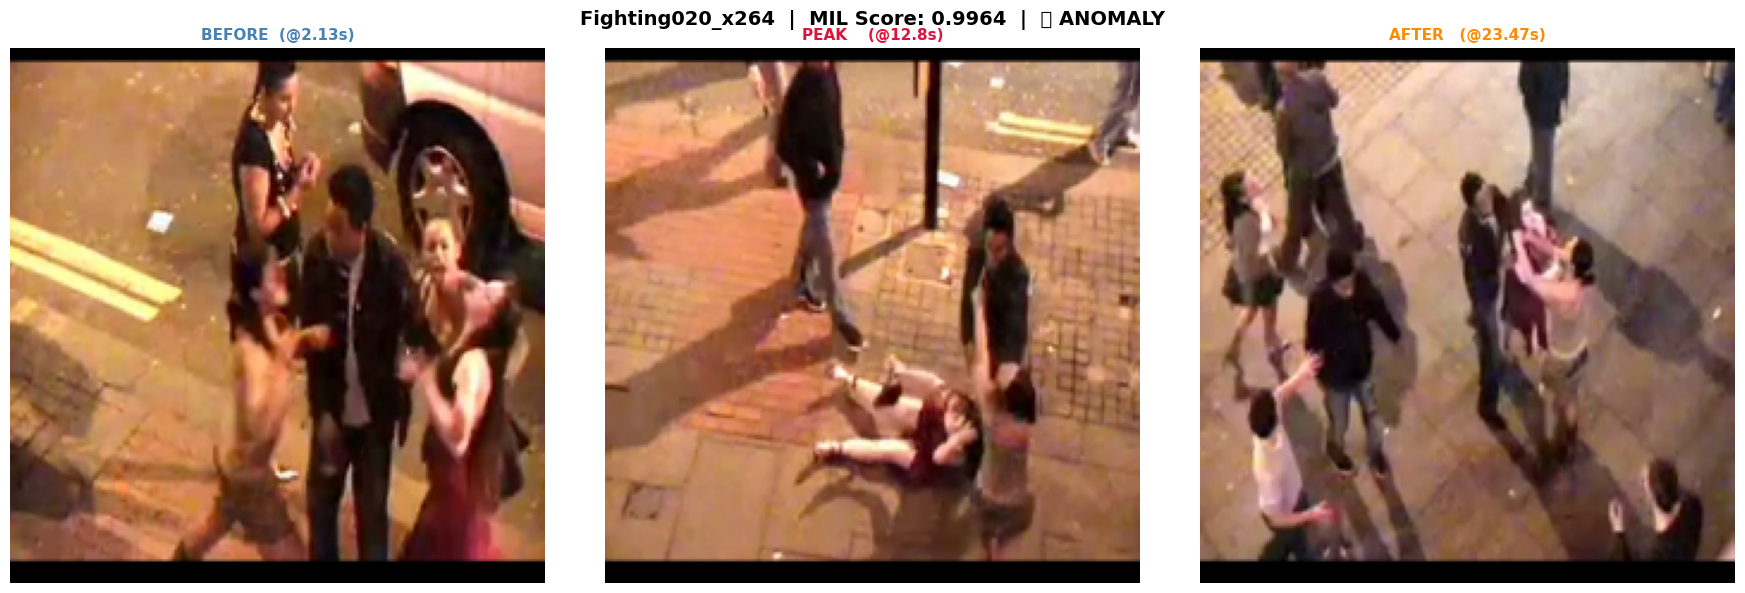

  💾 Figure saved: F:\2014741\Stage2_Captions\Fighting020_x264_frames.png


In [8]:
"""
Visualize the 3 extracted frames side by side with their captions.
"""

def visualize_stage2(result: Dict):
    """Display Before / Peak / After frames with captions."""
    if result is None:
        print("No result to visualize (video was normal).")
        return

    frames   = result['frames']
    captions = result['captions']
    ts       = result['timestamps']
    score    = result['mil_result']['video_score']

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        f"{result['video_name']}  |  MIL Score: {score}  |  🔴 ANOMALY",
        fontsize=14, fontweight='bold'
    )

    labels = ['before', 'peak', 'after']
    titles = [
        f"BEFORE  (@{ts['before']}s)",
        f"PEAK    (@{ts['peak']}s)",
        f"AFTER   (@{ts['after']}s)",
    ]
    colors = ['steelblue', 'crimson', 'darkorange']

    for ax, label, title, color in zip(axes, labels, titles, colors):
        frame = frames.get(label)
        if frame is not None:
            ax.imshow(frame)
        else:
            ax.text(0.5, 0.5, 'Frame not available',
                    ha='center', va='center', transform=ax.transAxes)

        ax.set_title(title, color=color, fontweight='bold', fontsize=11)
        ax.axis('off')

        # Add caption below
        cap_text = captions.get(label, '')
        ax.set_xlabel(cap_text, fontsize=8, wrap=True,
                      labelpad=10, color='#333333')

    plt.tight_layout()
    plt.show()

    # Also save the figure
    fig_path = os.path.join(STAGE2_OUT, f"{result['video_name']}_frames.png")
    fig.savefig(fig_path, dpi=120, bbox_inches='tight')
    print(f"  💾 Figure saved: {fig_path}")


if stage2_result:
    visualize_stage2(stage2_result)

---
## Section 8: Stage 2 Output Format
This is exactly what Stage 3 (RAG + LLM) will receive.

---

In [9]:
"""
Show what Stage 2 passes to Stage 3.
Stage 3 needs only: video_name, video_score, scene_description
"""

if stage2_result:
    stage3_input = {
        "video_name"       : stage2_result['video_name'],
        "mil_score"        : stage2_result['mil_result']['video_score'],
        "peak_segment"     : stage2_result['mil_result']['peak_segment'],
        "scene_description": stage2_result['scene_description'],
    }

    print("=" * 60)
    print("STAGE 2 → STAGE 3 HANDOFF")
    print("=" * 60)
    print(json.dumps(stage3_input, indent=2))
    print("=" * 60)
    print("✅ Stage 2 COMPLETE")
    print("   Next: Stage 3 — RAG + LLM Classification & Explanation")
    print("=" * 60)

STAGE 2 → STAGE 3 HANDOFF
{
  "video_name": "Fighting020_x264",
  "mil_score": 0.9964,
  "peak_segment": 3,
  "scene_description": "Before the incident: In the frame, there are several individuals gathered on a street. One person is being held by another individual, who appears to be restraining or controlling the situation. The person being restrained is positioned in the center of the frame, with their back to the camera. The restraining individual is standing to the right of the restrained person, facing them. There are other people in the background, some of whom are observing the situation. The environment is an urban street with a car visible on the right side of the frame. The lighting suggests it is daytime. During the incident: The image depicts a scene where a person is lying on the ground, seemingly unconscious or injured. The individual is lying on their back, with their legs extended and arms slightly raised. There are two other individuals standing over the person, one of